# Figure 1 — kardemumma architecture diagram

Three-stage pipeline diagram (`preview` → `cutoff` → `report`) with the library
modules from **Table 1** mapped onto each CLI step, plus the two auxiliary
commands (`kardemumma-ipynb`, `kardemumma-docs`) that sit across the whole
pipeline.

Run all cells to render `figure1_architecture.pdf` and `.pdf`'s PNG preview
into `paper/`.

In [1]:
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

OUT_DIR = Path(".").resolve()

# Categorical palette (dataviz skill: slots 1/2/3 — blue/orange/aqua, the
# only ordering that clears every colorblind-safety gate on all 3 pairs at once).
STAGE_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
SURFACE = "#fcfcfb"


def tint(hex_color, amount=0.92):
    hex_color = hex_color.lstrip("#")
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    r = r + (255 - r) * amount
    g = g + (255 - g) * amount
    b = b + (255 - b) * amount
    return (r / 255, g / 255, b / 255)


In [2]:
def rounded_box(ax, x0, y0, x1, y1, facecolor, edgecolor, lw=1.3, zorder=2):
    ax.add_patch(FancyBboxPatch(
        (x0, y0), x1 - x0, y1 - y0,
        boxstyle="round,pad=0,rounding_size=0.1",
        linewidth=lw, edgecolor=edgecolor, facecolor=facecolor, zorder=zorder,
    ))


def arrow(ax, p0, p1, color=INK_MUTED, lw=2.0, zorder=1):
    ax.add_patch(FancyArrowPatch(
        p0, p1, arrowstyle="-|>", mutation_scale=15,
        linewidth=lw, color=color, zorder=zorder, shrinkA=1, shrinkB=1,
    ))


def stage_box(ax, x0, x1, top, bot, color, step_no, cli_name, rows,
              wrap_width=42, footnote=None, header_h=0.58):
    rounded_box(ax, x0, top, x1, bot, facecolor="white", edgecolor=color, lw=1.6, zorder=2)
    rounded_box(ax, x0, bot - header_h, x1, bot, facecolor=color, edgecolor=color, lw=1.6, zorder=3)
    cx = (x0 + x1) / 2
    ax.text(cx, bot - header_h / 2 + 0.065, f"STEP {step_no}",
            ha="center", va="center", fontsize=9.5, fontweight="bold", color="white", zorder=4)
    ax.text(cx, bot - header_h / 2 - 0.185, cli_name,
            ha="center", va="center", fontsize=10.2, fontweight="bold", color="white",
            fontfamily="monospace", zorder=4)

    label_h, line_h, gap = 0.27, 0.225, 0.20
    wrapped_rows = [(cat, textwrap.wrap(funcs, wrap_width)) for cat, funcs in rows]
    content_h = sum(label_h + line_h * len(lines) + gap for _, lines in wrapped_rows) - gap

    body_top = bot - header_h - 0.18
    body_bottom = top + (0.38 if footnote else 0.18)
    y = body_top - max(0.0, (body_top - body_bottom - content_h) / 2)
    for cat, lines in wrapped_rows:
        ax.text(x0 + 0.2, y, cat, ha="left", va="top", fontsize=8.8,
                fontweight="bold", color=color, zorder=4)
        y -= label_h
        for line in lines:
            ax.text(x0 + 0.2, y, line, ha="left", va="top", fontsize=7.4,
                    color=INK_SECONDARY, fontfamily="monospace", zorder=4)
            y -= line_h
        y -= gap

    if footnote:
        ax.text(x0 + 0.2, top + 0.16, footnote, ha="left", va="bottom",
                fontsize=6.9, color=INK_MUTED, style="italic", zorder=4)


def side_box(ax, x0, x1, y0, y1, title, body, title_color=INK, fontsize=8.1):
    rounded_box(ax, x0, y0, x1, y1, facecolor=tint(INK_MUTED, 0.94), edgecolor=INK_MUTED, lw=1.1, zorder=2)
    ax.text(x0 + 0.2, y1 - 0.27, title, ha="left", va="top", fontsize=9.3, fontweight="bold",
            color=title_color, zorder=3)
    ax.text(x0 + 0.2, y1 - 0.6, body, ha="left", va="top", fontsize=fontsize, color=INK_SECONDARY,
            zorder=3, linespacing=1.6)


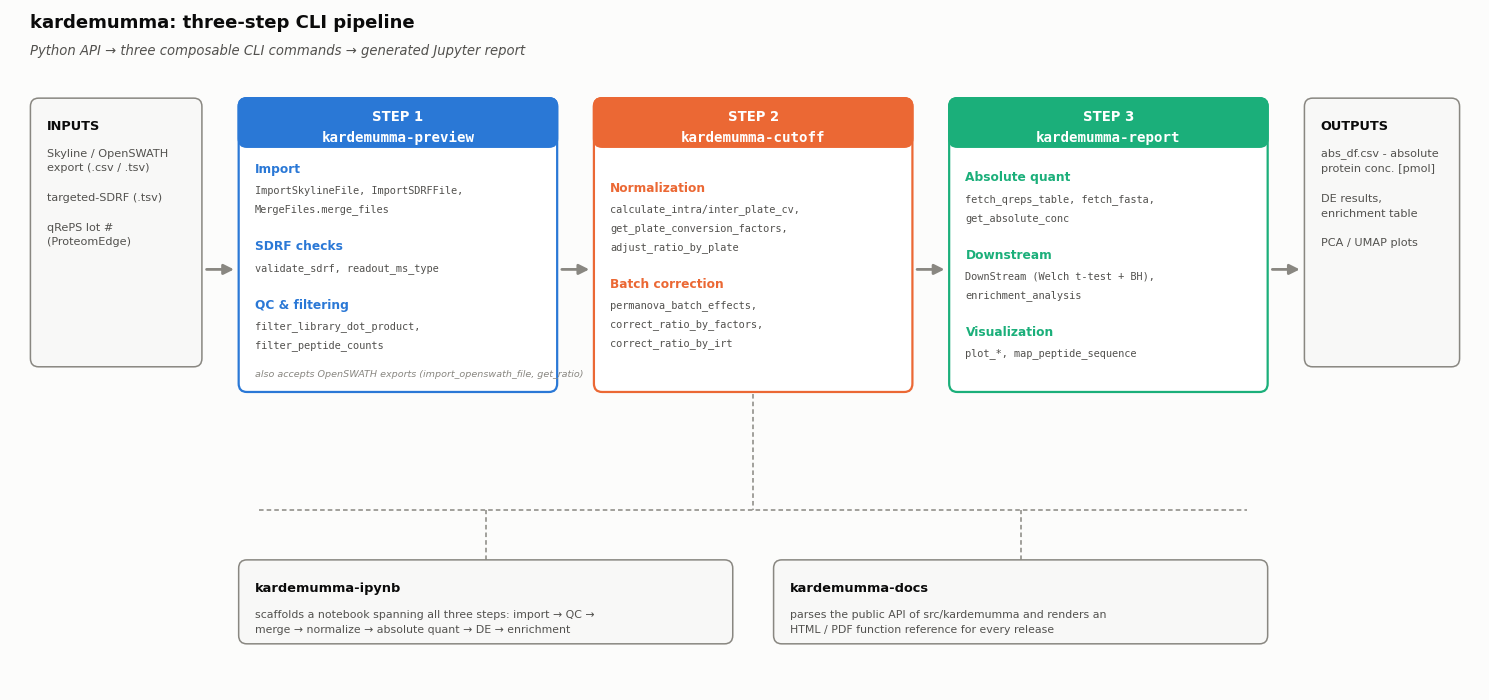

In [3]:
fig, ax = plt.subplots(figsize=(15, 7.1))
XLIM, YLIM = 18.0, 8.1
ax.set_xlim(0, XLIM)
ax.set_ylim(0, YLIM)
ax.axis("off")
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

STAGE_TOP, STAGE_BOT = 3.55, 7.05

# geometry: inputs | step 1 | step 2 | step 3 | outputs
IN_X0, IN_X1 = 0.25, 2.35
S1_X0, S1_X1 = 2.8, 6.7
S2_X0, S2_X1 = 7.15, 11.05
S3_X0, S3_X1 = 11.5, 15.4
OUT_X0, OUT_X1 = 15.85, 17.75

side_box(
    ax, IN_X0, IN_X1, STAGE_TOP + 0.3, STAGE_BOT,
    "INPUTS",
    "Skyline / OpenSWATH\nexport (.csv / .tsv)\n\ntargeted-SDRF (.tsv)\n\nqRePS lot #\n(ProteomEdge)",
)

side_box(
    ax, OUT_X0, OUT_X1, STAGE_TOP + 0.3, STAGE_BOT,
    "OUTPUTS",
    "abs_df.csv - absolute\nprotein conc. [pmol]\n\nDE results,\nenrichment table\n\nPCA / UMAP plots",
)

stage_box(
    ax, S1_X0, S1_X1, STAGE_TOP, STAGE_BOT, STAGE_COLORS[0], 1, "kardemumma-preview",
    [
        ("Import", "ImportSkylineFile, ImportSDRFFile, MergeFiles.merge_files"),
        ("SDRF checks", "validate_sdrf, readout_ms_type"),
        ("QC & filtering", "filter_library_dot_product, filter_peptide_counts"),
    ],
    footnote="also accepts OpenSWATH exports (import_openswath_file, get_ratio)",
)

stage_box(
    ax, S2_X0, S2_X1, STAGE_TOP, STAGE_BOT, STAGE_COLORS[1], 2, "kardemumma-cutoff",
    [
        ("Normalization", "calculate_intra/inter_plate_cv, get_plate_conversion_factors, adjust_ratio_by_plate"),
        ("Batch correction", "permanova_batch_effects, correct_ratio_by_factors, correct_ratio_by_irt"),
    ],
)

stage_box(
    ax, S3_X0, S3_X1, STAGE_TOP, STAGE_BOT, STAGE_COLORS[2], 3, "kardemumma-report",
    [
        ("Absolute quant", "fetch_qreps_table, fetch_fasta, get_absolute_conc"),
        ("Downstream", "DownStream (Welch t-test + BH), enrichment_analysis"),
        ("Visualization", "plot_*, map_peptide_sequence"),
    ],
)

mid_y = STAGE_TOP + (STAGE_BOT - 0.58 - STAGE_TOP) / 2
arrow(ax, (IN_X1 + 0.04, mid_y), (S1_X0 - 0.04, mid_y))
arrow(ax, (S1_X1 + 0.04, mid_y), (S2_X0 - 0.04, mid_y))
arrow(ax, (S2_X1 + 0.04, mid_y), (S3_X0 - 0.04, mid_y))
arrow(ax, (S3_X1 + 0.04, mid_y), (OUT_X0 - 0.04, mid_y))

# auxiliary CLI tools spanning the pipeline
AUX_Y0, AUX_Y1 = 0.55, 1.55
BRACKET_Y = 2.15
pipe_mid_x = (S1_X0 + S3_X1) / 2
ax.plot([pipe_mid_x, pipe_mid_x], [STAGE_TOP - 0.03, BRACKET_Y], color=INK_MUTED, lw=1.1,
        linestyle=(0, (3, 2)), zorder=0)
ax.plot([S1_X0 + 0.25, S3_X1 - 0.25], [BRACKET_Y, BRACKET_Y], color=INK_MUTED, lw=1.1,
        linestyle=(0, (3, 2)), zorder=0)

AUX1_X0, AUX1_X1 = S1_X0, pipe_mid_x - 0.25
AUX2_X0, AUX2_X1 = pipe_mid_x + 0.25, S3_X1
for cx in ((AUX1_X0 + AUX1_X1) / 2, (AUX2_X0 + AUX2_X1) / 2):
    ax.plot([cx, cx], [AUX_Y1, BRACKET_Y], color=INK_MUTED, lw=1.1, linestyle=(0, (3, 2)), zorder=0)

side_box(
    ax, AUX1_X0, AUX1_X1, AUX_Y0, AUX_Y1,
    "kardemumma-ipynb",
    "scaffolds a notebook spanning all three steps: import \u2192 QC \u2192\nmerge \u2192 normalize \u2192 absolute quant \u2192 DE \u2192 enrichment",
    fontsize=7.9,
)
side_box(
    ax, AUX2_X0, AUX2_X1, AUX_Y0, AUX_Y1,
    "kardemumma-docs",
    "parses the public API of src/kardemumma and renders an\nHTML / PDF function reference for every release",
    fontsize=7.9,
)

ax.text(0.25, YLIM - 0.05, "kardemumma: three-step CLI pipeline", fontsize=13, fontweight="bold",
        color=INK, ha="left", va="top")
ax.text(0.25, YLIM - 0.4, "Python API \u2192 three composable CLI commands \u2192 generated Jupyter report",
        fontsize=9.5, color=INK_SECONDARY, ha="left", va="top", style="italic")

fig.tight_layout()
plt.show()


In [4]:
pdf_path = OUT_DIR / "figure1_architecture.pdf"
png_path = OUT_DIR / "figure1_architecture.png"
fig.savefig(pdf_path, facecolor=SURFACE, bbox_inches="tight")
fig.savefig(png_path, dpi=220, facecolor=SURFACE, bbox_inches="tight")
print(f"Wrote {pdf_path}")
print(f"Wrote {png_path}")


Wrote /home/thanadol/Documents/GitHub/kardemumma/paper/figure1_architecture.pdf
Wrote /home/thanadol/Documents/GitHub/kardemumma/paper/figure1_architecture.png
